In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt

In [3]:

cards = pd.read_csv(Path.cwd().parent.parent / "archive" / "cards_data.csv")
cards.drop(columns=['card_number', 'cvv'], inplace=True)
cards = cards.rename(columns={'id': 'card_id'})
cards.head()

,card_id,client_id,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,12/2022,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,12/2020,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,02/2024,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,08/2024,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),03/2009,YES,1,$28,09/2008,2009,No


In [4]:
users = pd.read_csv(Path.cwd().parent.parent / "archive" / "users_data.csv")
users = users.rename(columns={'id': 'client_id'})
users.drop(columns=['birth_year', 'birth_month', 'address', 'latitude', 'longitude'], inplace=True)
users.head()

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,Female,$29278,$59696,$127613,787,5
1,1746,53,68,Female,$37891,$77254,$191349,701,5
2,1718,81,67,Female,$22681,$33483,$196,698,5
3,708,63,63,Female,$163145,$249925,$202328,722,4
4,1164,43,70,Male,$53797,$109687,$183855,675,1


In [5]:
transactions = pd.read_csv(Path.cwd().parent.parent / "archive" / "transactions_data.csv")
transactions = transactions.drop(columns=['merchant_id', 'merchant_city', 'merchant_state', 'zip'])
transactions.head()

,id,date,client_id,card_id,amount,use_chip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,5813,NaN


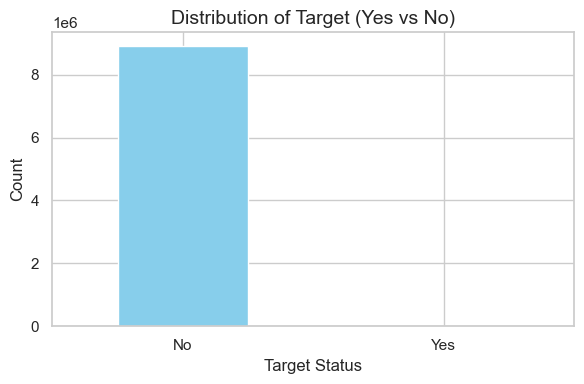

In [6]:
with open (Path.cwd().parent.parent / "archive" / "train_fraud_labels.json", 'r') as f:
    raw = json.load(f)
labels = pd.DataFrame(raw)

labels.reset_index(inplace=True)
labels.rename(columns={'index': 'id'}, inplace=True)
labels['id'] = labels['id'].astype('int64')

target_counts = labels['target'].value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Distribution of Target (Yes vs No)', fontsize=14)
plt.xlabel('Target Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

Potential class imbalance

In [7]:
labels.head()

,id,target
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


In [8]:
df = (transactions
        .merge(users, on="client_id", how="left")
        .merge(cards, on=["card_id", "client_id"], how="left")
        .merge(labels, on="id", how="left")
    )

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.head()

,id,date,client_id,card_id,amount,use_chip,mcc,errors,current_age,retirement_age,...,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,target
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,5499,NaN,30,67,...,Mastercard,Debit (Prepaid),07/2022,YES,2,$55,05/2008,2008,No,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,5311,NaN,48,67,...,Mastercard,Credit,12/2024,YES,1,$9100,09/2005,2015,No,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,4829,NaN,49,65,...,Mastercard,Debit,05/2020,YES,1,$14802,01/2006,2008,No,No
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,4829,NaN,52,67,...,Mastercard,Debit,10/2024,NO,2,$37634,05/2004,2006,No,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,5813,NaN,51,69,...,Visa,Debit,01/2020,YES,1,$19113,07/2009,2014,No,No


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime is datetime type
df['date'] = pd.to_datetime(df['date'])

# Time features
df['weekday'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month_name()
df['day_of_year'] = df['date'].dt.dayofyear

In [12]:
df_yes = df[df['target'] == 'Yes'].copy()

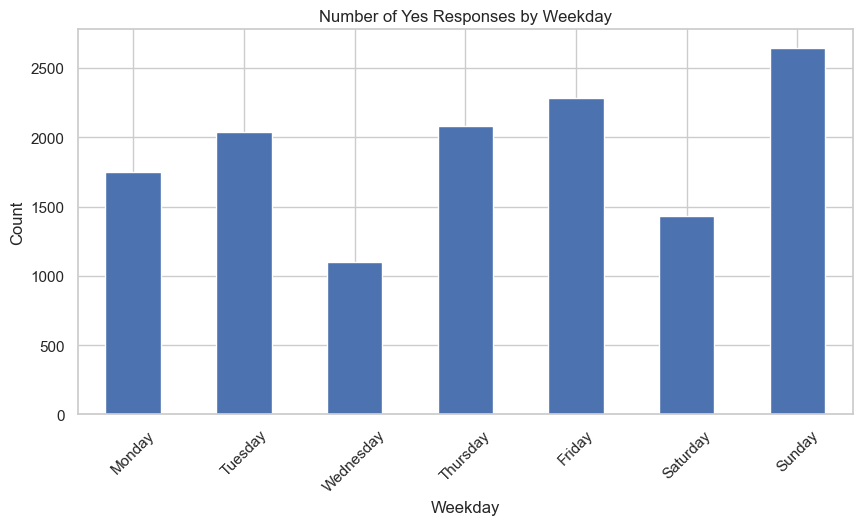

In [13]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday_counts = (
    df_yes['weekday']
    .value_counts()
    .reindex(weekday_order)
)

weekday_counts.plot(
    kind='bar',
    figsize=(10, 5),
    title='Number of Yes Responses by Weekday'
)

plt.xlabel('Weekday')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

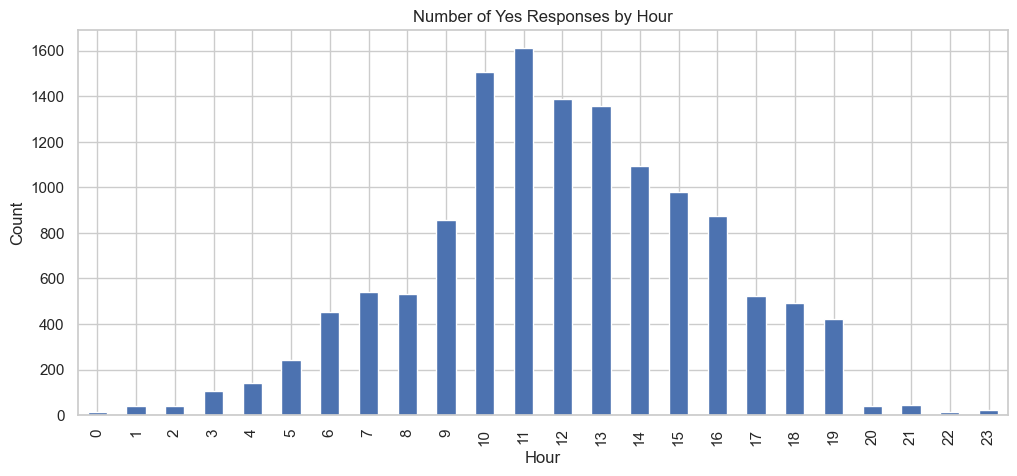

In [14]:
hour_counts = (
    df_yes['hour']
    .value_counts()
    .sort_index()
)

hour_counts.plot(
    kind='bar',
    figsize=(12, 5),
    title='Number of Yes Responses by Hour'
)

plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

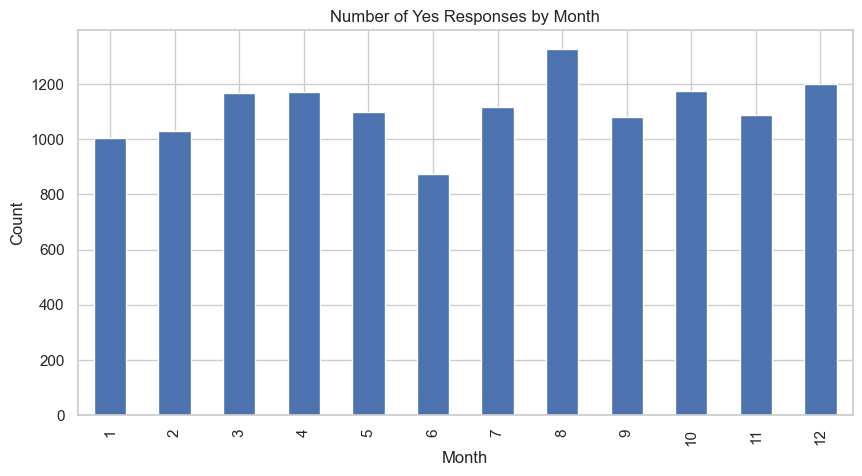

In [15]:
month_counts = (
    df_yes['date']
    .dt.month
    .value_counts()
    .sort_index()
)

month_counts.plot(
    kind='bar',
    figsize=(10, 5),
    title='Number of Yes Responses by Month'
)

plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

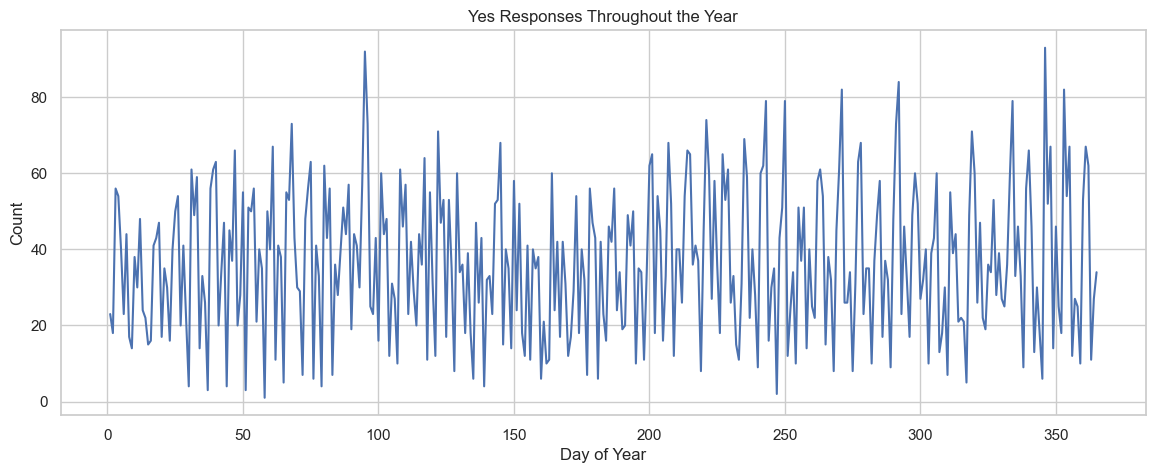

In [16]:
daily_counts = (
    df_yes['date']
    .dt.dayofyear
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 5))
daily_counts.plot()
plt.title('Yes Responses Throughout the Year')
plt.xlabel('Day of Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [17]:
df['target'].value_counts(dropna=False)
df['target'].value_counts(normalize=True) * 100

target
No     99.850454
Yes     0.149546
Name: proportion, dtype: float64

In [18]:
df['amount_num'] = (
    df['amount']
      .str.replace('$', '', regex=False)
      .astype(float)
)

In [19]:
df.groupby('target')['amount_num'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
No,8901631.0,42.848614,81.125350,-500.0,8.920,28.950,63.5700,6613.44
Yes,13332.0,110.234682,213.736207,-500.0,17.835,69.975,148.4925,4978.45


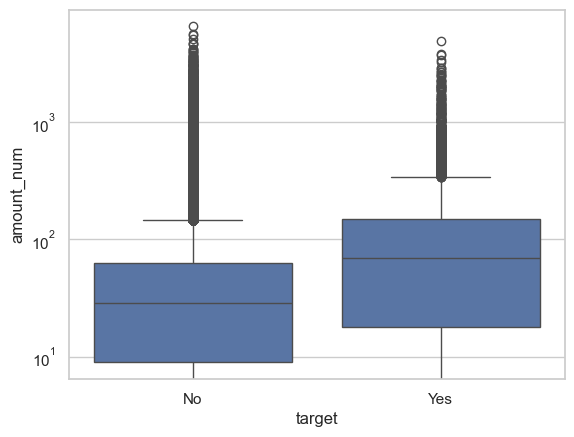

In [20]:
sns.boxplot(data=df, x='target', y='amount_num')
plt.yscale('log')

In [21]:
mcc_target = (
    pd.crosstab(df['mcc'], df['target'], normalize='index')
      .sort_values('Yes', ascending=False)
)

mcc_target.head(20)

target,No,Yes
mcc,,
4411,0.402174,0.597826
5733,0.627451,0.372549
3006,0.881633,0.118367
5045,0.891662,0.108338
3144,0.896396,0.103604
3005,0.914062,0.085938
5732,0.914267,0.085733
3009,0.919414,0.080586
5094,0.931348,0.068652


In [22]:
pd.crosstab(
    df['use_chip'],
    df['target'],
    normalize='index'
)

target,No,Yes
use_chip,,
Chip Transaction,0.999008,0.000992
Online Transaction,0.991591,0.008409
Swipe Transaction,0.999705,0.000295


In [23]:
pd.crosstab(
    df['card_type'],
    df['target'],
    normalize='index'
)

target,No,Yes
card_type,,
Credit,0.998369,0.001631
Debit,0.998655,0.001345
Debit (Prepaid),0.997753,0.002247


<Axes: xlabel='target', ylabel='credit_limit_num'>

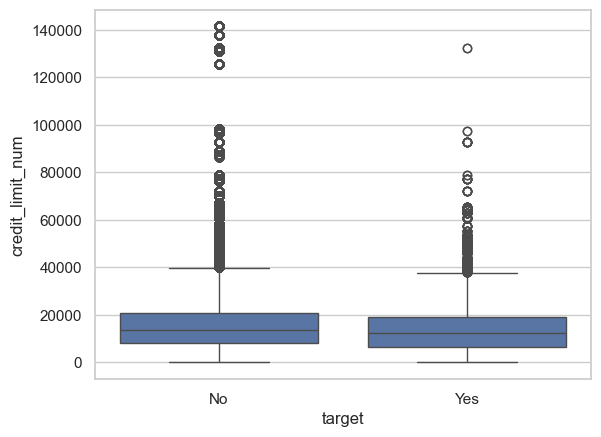

In [24]:
df['credit_limit_num'] = (
    df['credit_limit']
      .str.replace('$', '', regex=False)
      .astype(float)
)

sns.boxplot(
    data=df,
    x='target',
    y='credit_limit_num'
)

Core Fraud Loss:

In [25]:
fraud_loss = df.loc[df['target'] == 'Yes', 'amount_num'].sum()

fraud_loss

print(f"Total Fraud Loss: ${fraud_loss:,.2f}")

Total Fraud Loss: $1,469,648.78


In [26]:
df['amount_num'].sum()
print(f"Total Transaction Amount: ${df['amount_num'].sum():,.2f}")

Total Transaction Amount: $571,835,522.28


In [27]:
fraud_rate = (df['target'].eq('Yes').mean()) * 100
fraud_rate

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 0.10%


In [28]:
total_volume = df['amount_num'].sum()
fraud_volume = fraud_loss

fraud_exposure_pct = fraud_volume / total_volume * 100
fraud_exposure_pct

print(f"Fraud Exposure Percentage: {fraud_exposure_pct:.2f}%")

Fraud Exposure Percentage: 0.26%


In [29]:
mcc_fraud = (
    df[df['target'] == 'Yes']
    .groupby('mcc')['amount_num']
    .sum()
    .sort_values(ascending=False)
)

mcc_fraud.head(10)

mcc
5311    225647.19
4411    185946.78
5300    113827.65
5310     81214.89
4829     66101.52
5732     61171.38
5712     56989.45
5719     34238.45
4814     33625.04
5651     30051.56
Name: amount_num, dtype: float64

In [30]:
df.pivot_table(
    index='use_chip',
    columns='target',
    values='amount_num',
    aggfunc='sum'
)

target,No,Yes
use_chip,,
Chip Transaction,1.305815e+08,280756.35
Online Transaction,5.866721e+07,1061612.39
Swipe Transaction,1.921739e+08,127280.04


In [31]:
df['date'].min(), df['date'].max()

(Timestamp('2010-01-01 00:01:00'), Timestamp('2019-10-31 23:59:00'))

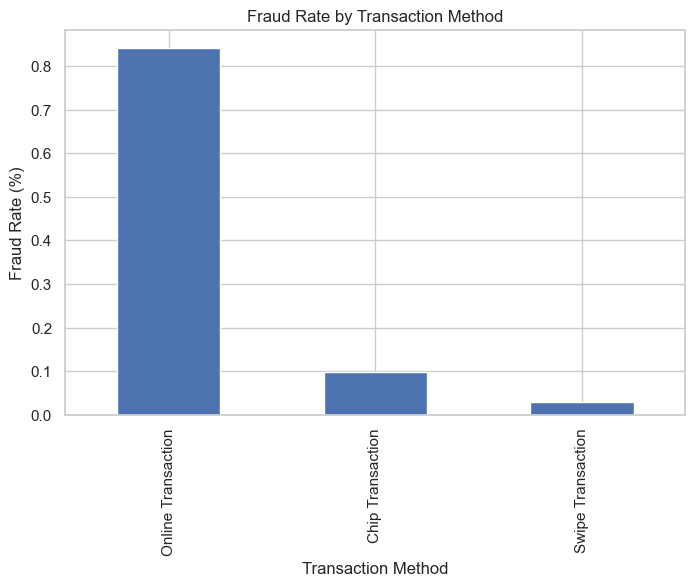

In [32]:
fraud_rate_chip = (
    pd.crosstab(df['use_chip'], df['target'], normalize='index')
      .mul(100)
)

fraud_rate_chip['Yes'].sort_values(ascending=False)

fraud_rate_chip['Yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Fraud Rate by Transaction Method')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Transaction Method')
plt.show()

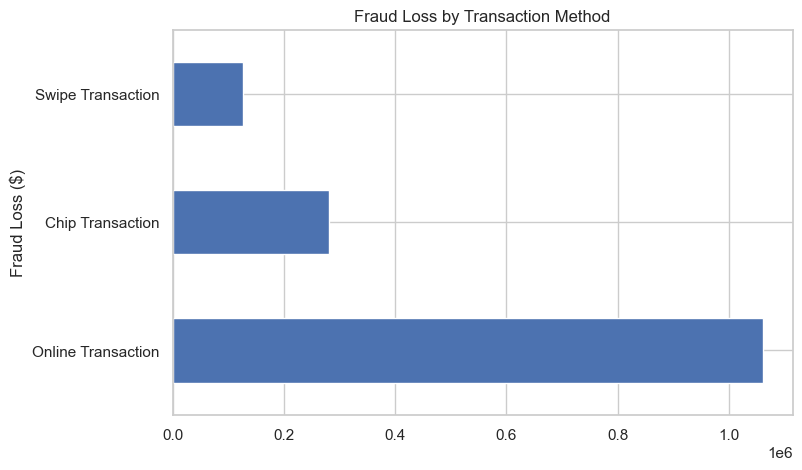

In [33]:
fraud = df[df['target'] == 'Yes']

fraud_loss_chip = (
    fraud.groupby('use_chip')['amount_num']
         .sum()
         .sort_values(ascending=False)
)

fraud_loss_chip.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Fraud Loss by Transaction Method')
plt.ylabel('Fraud Loss ($)')
plt.show()

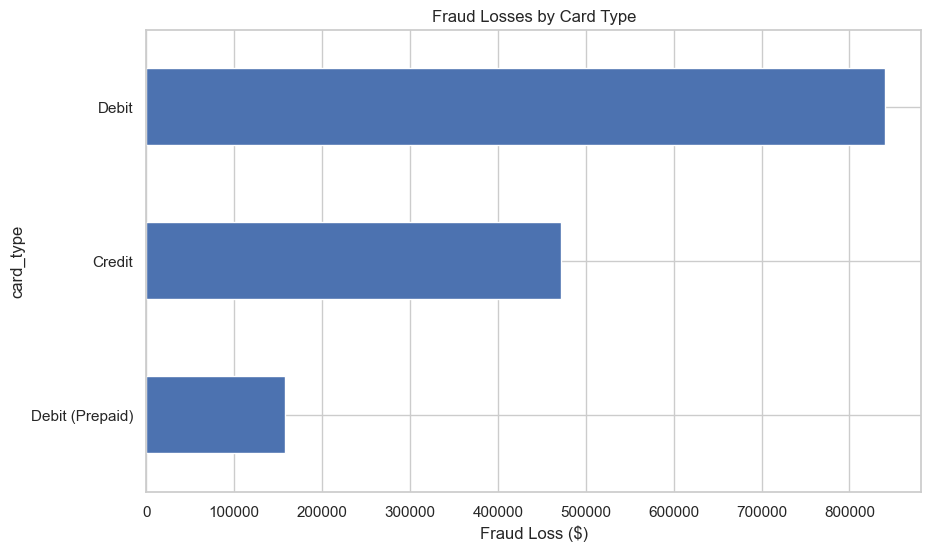

In [34]:
fraud.groupby('card_type')['amount_num'] \
     .sum() \
     .sort_values() \
     .plot(kind='barh', figsize=(10,6))

plt.title('Fraud Losses by Card Type')
plt.xlabel('Fraud Loss ($)')
plt.show()

/var/folders/q7/3_x5zwtn1tz73121ks83471m0000gn/T/ipykernel_33553/3815559155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud['year_month'] = fraud['date'].dt.to_period('M')


<Axes: xlabel='year_month'>

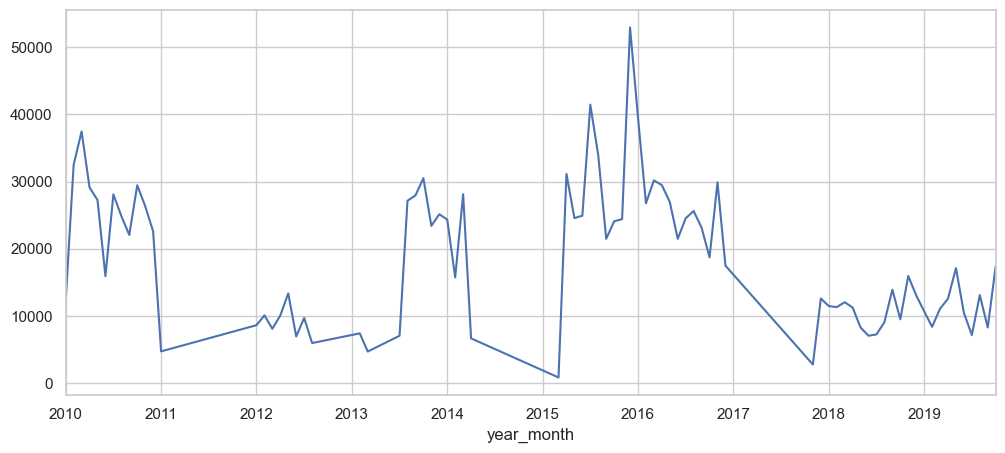

In [35]:
fraud['year_month'] = fraud['date'].dt.to_period('M')

monthly_loss = fraud.groupby('year_month')['amount_num'].sum()

monthly_loss.plot(figsize=(12,5))

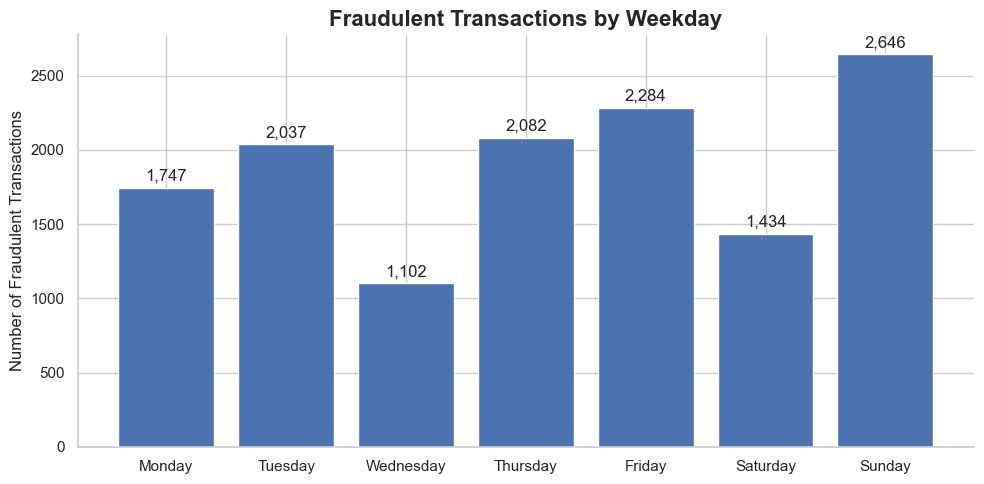

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    weekday_counts.index,
    weekday_counts.values
)

ax.set_title(
    'Fraudulent Transactions by Weekday',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Number of Fraudulent Transactions')

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

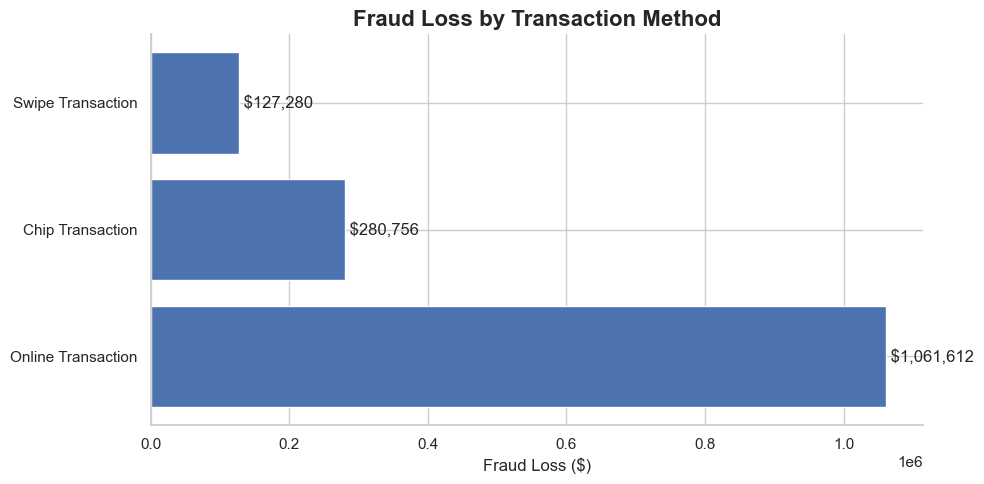

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    fraud_loss_chip.index,
    fraud_loss_chip.values
)

ax.set_title(
    'Fraud Loss by Transaction Method',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Fraud Loss ($)')
ax.set_ylabel('')

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' ${width:,.0f}',
        va='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

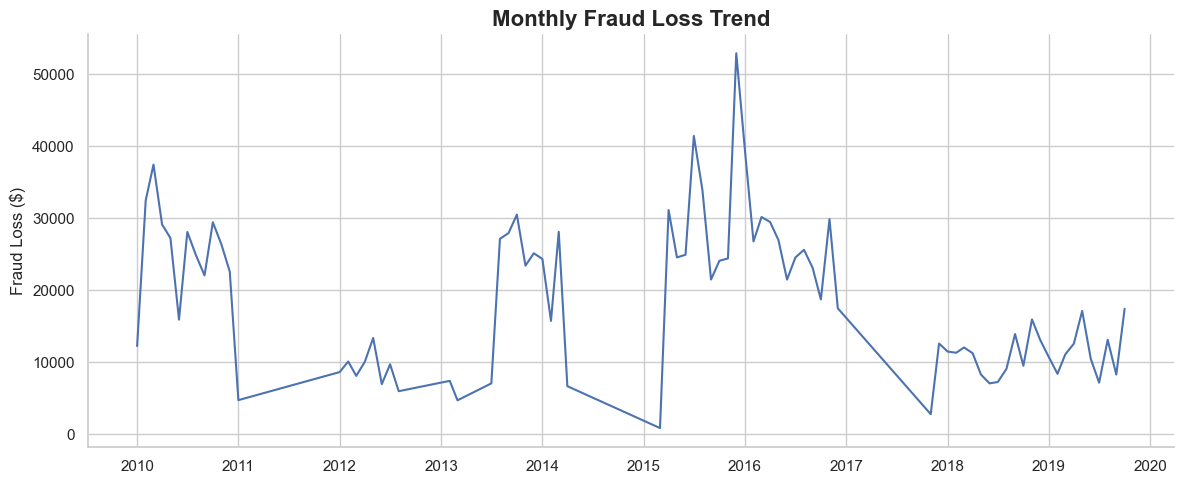

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

# convert PeriodIndex -> datetime for better control
monthly_loss.index = monthly_loss.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(monthly_loss.index, monthly_loss.values)

ax.set_title('Monthly Fraud Loss Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Fraud Loss ($)')

# show only yearly ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

sns.despine()
plt.tight_layout()
plt.show()

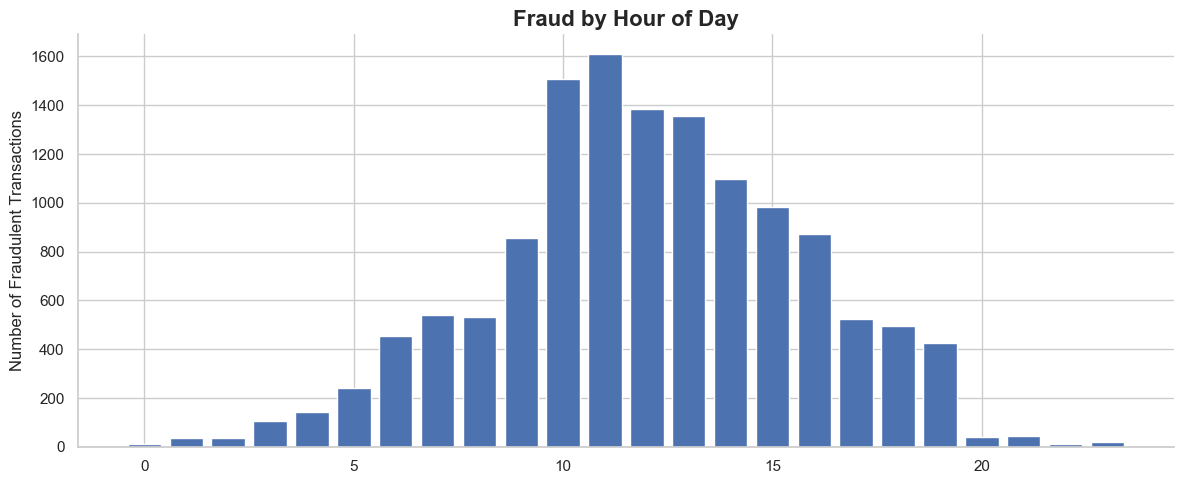

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

hour_counts = (
    df_yes['hour']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(hour_counts.index, hour_counts.values)

ax.set_title(
    'Fraud by Hour of Day',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Number of Fraudulent Transactions')

sns.despine()
plt.tight_layout()
plt.show()

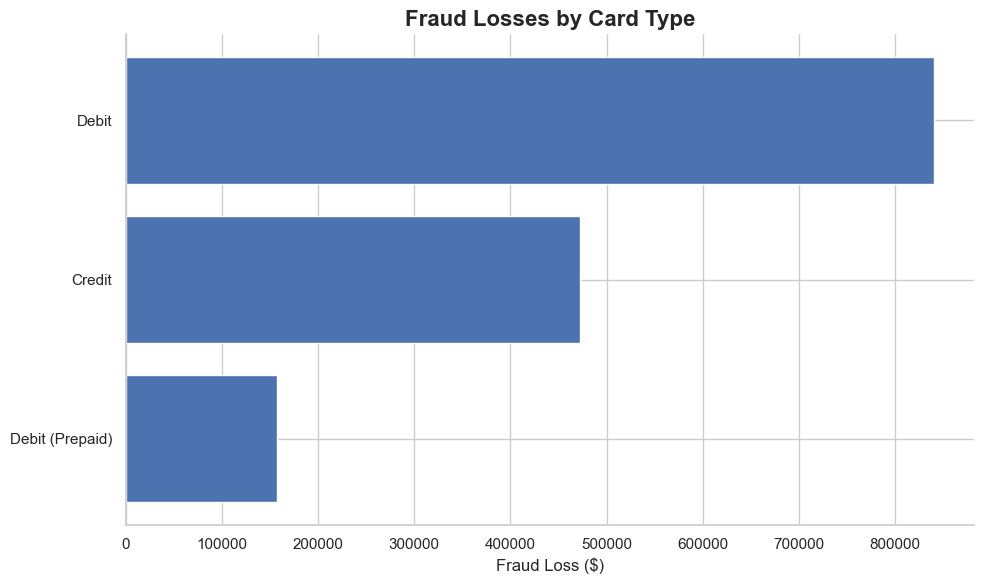

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fraud_card = (
    fraud.groupby('card_type')['amount_num']
         .sum()
         .sort_values()
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(fraud_card.index, fraud_card.values)

ax.set_title(
    'Fraud Losses by Card Type',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Fraud Loss ($)')
ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()